# IoT Traffic Analysis — Experimental (ML device types + DL streaming RAW vs MASKED)

This version fixes two practical issues:

1) **No OOM**: DL uses **Scapy `PcapReader`** + `tf.data` streaming (no giant arrays).
2) **No "stuck after training"**: training datasets use `.repeat()` and we set `steps_per_epoch`,
   so Keras never runs out of data mid-epoch.

DL variants:
- **DL-RAW**: first `MAX_LEN` bytes of packet
- **DL-MASKED**: strip Ethernet (MAC) + mask IP src/dst + mask TCP/UDP ports before bytes

DL split:
- **File-level train/test split** (pcap files), more realistic than packet-level split.


In [1]:
# 1) Imports & configuration
import os, glob, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import ExtraTreesClassifier

# DL
import tensorflow as tf
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout

# PCAP (true streaming)
from scapy.all import PcapReader, Ether, IP, TCP, UDP

RANDOM_STATE = 43
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

# Dataset paths (edit to your local structure)
FLOW_DATA_GLOB = "unsw-dataset/flows/*.csv"
PCAP_DATA_GLOB = "unsw-dataset/pcaps/*.pcap"

# Sampling (recommended on 16GB RAM)
CANTIDAD_META_FLOWS = 250_000   # sampled during load across flow CSVs
CANTIDAD_META_PKTS_PER_EPOCH = 100_000  # packets per epoch (streamed), per RAW or MASKED run

# Flow leakage drop list (aligned with your earlier work)
DROP_COLS = ['time','srcMac','dstMac','ethType','srcIp','dstIp','ipProto','srcPort','dstPort','flowSeqNum']

# DL params
MAX_LEN = 500
BATCH_SIZE = 512
EPOCHS = 3

steps_per_epoch = int(np.ceil(CANTIDAD_META_PKTS_PER_EPOCH / BATCH_SIZE))
print("steps_per_epoch:", steps_per_epoch)


2026-01-12 17:20:54.579777: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-01-12 17:20:54.657142: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-01-12 17:20:57.438859: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


steps_per_epoch: 196


## 2) Flow-based ML — hardcoded device type labels

In [2]:
# 2a) Load flow CSVs with sampling during load (memory-friendly)
file_paths = sorted(glob.glob(FLOW_DATA_GLOB))
if not file_paths:
    raise FileNotFoundError(f"No flow CSVs found for pattern: {FLOW_DATA_GLOB}")

n_files = len(file_paths)
target = CANTIDAD_META_FLOWS
per_file_quota = None if target is None else max(1, target // n_files)

df_list = []
total_loaded = 0

for fp in file_paths:
    device_name = os.path.basename(fp).replace("_flows.csv", "")
    df_full = pd.read_csv(fp, low_memory=False)

    if per_file_quota is None:
        df = df_full
    else:
        df = df_full.sample(n=min(len(df_full), per_file_quota), random_state=RANDOM_STATE)

    df["device"] = device_name
    df_list.append(df)
    total_loaded += len(df)
    print(f"{device_name}: loaded {len(df):,} flows (running total {total_loaded:,})")

df_all = pd.concat(df_list, ignore_index=True)
print(f"Total flows loaded: {len(df_all):,} from {df_all['device'].nunique()} devices.")
print("Approx df_all RAM (MB):", round(df_all.memory_usage(deep=True).sum()/1024**2, 2))
display(df_all.head())


AmazonEcho_44650d56ccd3: loaded 9,259 flows (running total 9,259)
AugustDoorBell_e076d03f00ae: loaded 9,259 flows (running total 18,518)
AwairAirQuality_70886b100fc6: loaded 4,406 flows (running total 22,924)
BelkinCamera_b4750eece5a9: loaded 9,259 flows (running total 32,183)
BelkinWemoMotionSensor_ec1a59832811: loaded 9,259 flows (running total 41,442)
BelkinWemoSwitch_ec1a5979f489: loaded 9,259 flows (running total 50,701)
BlipCareBPMeter_746a89002e25: loaded 54 flows (running total 50,755)
CanaryCamera_7c70bc5d5edc: loaded 6,598 flows (running total 57,353)
HPPrinter_705a0fe49bc0: loaded 9,259 flows (running total 66,612)
HelloBarbie_28c2ddffa52d: loaded 150 flows (running total 66,762)
LiFXBulb_d073d5018308: loaded 9,259 flows (running total 76,021)
NestDropCam_308cfb2fe4b2: loaded 2,108 flows (running total 78,129)
NestProtect_18b43025bee4: loaded 9,259 flows (running total 87,388)
NetatmoWeatherStation_70ee5003b8ac: loaded 9,259 flows (running total 96,647)
NetatmoWelcome_70ee50

,time,srcMac,dstMac,ethType,srcIp,dstIp,ipProto,srcPort,dstPort,flowSeqNum,...,flowDuration,srcAvgInterarrivalTime,dstAvgInterarrivalTime,avgInterarrivalTime,srcStdDevInterarrivalTime,dstStdDevInterarrivalTime,stdDevInterarrivalTime,allMatchedProtocols,protocol,device
0,2016-11-07 23:00:22.21215,NaN,NaN,0x0800,192.168.1.240,208.67.220.220,1,*,*,10628,...,10.0,3.25,3.25,1.111,1.299,1.299,1.370,icmp|,icmp,AmazonEcho_44650d56ccd3
1,2017-03-12 16:31:24.444346,NaN,NaN,0x0800,192.168.1.239,192.168.1.1,17,33250,53,1,...,0.0,0.00,0.00,0.000,0.000,0.000,0.000,dns|,dns,AmazonEcho_44650d56ccd3
2,2016-11-18 04:04:22.179638,NaN,NaN,0x0800,192.168.1.239,192.168.1.159,6,44084,80,1,...,2.0,0.00,1.00,0.667,0.000,1.000,0.943,http|,http,AmazonEcho_44650d56ccd3
3,2017-03-20 10:57:07.337618,NaN,NaN,0x0800,192.168.1.239,8.8.8.8,17,43654,53,1,...,2.0,0.00,0.00,2.000,0.000,0.000,0.000,dns|,dns,AmazonEcho_44650d56ccd3
4,2016-10-19 00:46:33.553805,NaN,NaN,0x0800,192.168.1.240,138.236.128.36,17,59589,123,27,...,197.0,0.00,0.00,197.000,0.000,0.000,0.000,ntp|,ntp,AmazonEcho_44650d56ccd3


In [3]:
# 2b) Hardcoded device -> type mapping (edit if you change taxonomy)
device_to_type = {
    # camera / streamer
    "SamsungCamera_00166cab6b88": "camera_streamer",
    "BelkinCamera_b4750eece5a9": "camera_streamer",
    "NestDropCam_308cfb2fe4b2": "camera_streamer",
    "TPLinkCamera_f4f26D9351f1": "camera_streamer",
    "CanaryCamera_7c70bc5d5edc": "camera_streamer",
    "NetatmoWelcome_70ee50183443": "camera_streamer",
    "WithingsBabyMonitor_0024e41118a8": "camera_streamer",
    "RingDoorBell_884aea31669d": "camera_streamer",
    "AugustDoorBell_e076d03f00ae": "camera_streamer",

    # sensors / meters
    "AwairAirQuality_70886b100fc6": "sensor_meter",
    "NetatmoWeatherStation_70ee5003b8ac": "sensor_meter",
    "WithingsSleepSensor_0024e42028c6": "sensor_meter",
    "WithingsSmartScale_0024e41b6f96": "sensor_meter",
    "BlipCareBPMeter_746a89002e25": "sensor_meter",
    "NestProtect_18b43025bee4": "sensor_meter",
    "BelkinWemoMotionSensor_ec1a59832811": "sensor_meter",

    # actuators / lights / plugs
    "PhilipsHue_0017882b9a25": "actuator_light_plug",
    "LiFXBulb_d073d5018308": "actuator_light_plug",
    "TPLinkSmartPlug_50c7bf005639": "actuator_light_plug",
    "BelkinWemoSwitch_ec1a5979f489": "actuator_light_plug",

    # hubs / infra
    "SamsungSmartThings_d052a800675e": "hub_gateway_bridge",
    "HPPrinter_705a0fe49bc0": "hub_gateway_bridge",

    # media / interactive
    "TribySpeaker_18B79E022044": "media_speaker_display",
    "PixStarPhotoFrame_e076d033bb85": "media_speaker_display",
    "HelloBarbie_28c2ddffa52d": "media_speaker_display",
    "iHome_74c63b29d71d": "media_speaker_display",
    "AmazonEcho_44650d56ccd3": "media_speaker_display",
}

df_all["device_type"] = df_all["device"].map(device_to_type)

missing = df_all.loc[df_all["device_type"].isna(), "device"].unique()
print("Devices missing mapping:", missing)

print("\nType distribution (flows):")
display(df_all["device_type"].value_counts(dropna=False).to_frame("n_flows"))


Devices missing mapping: []

Type distribution (flows):


,n_flows
device_type,
camera_streamer,65365
sensor_meter,43026
media_speaker_display,37186
actuator_light_plug,37036
hub_gateway_bridge,18518


In [4]:
# 2c) Train ML classifier on flows -> device_type (group split by device)
df_labeled = df_all.dropna(subset=["device_type"]).copy()

cols_to_drop = [c for c in DROP_COLS if c in df_labeled.columns]
X = df_labeled.drop(columns=cols_to_drop + ["device", "device_type"], errors="ignore")
y = df_labeled["device_type"].astype(str)
groups = df_labeled["device"]

# Numeric-only recommended (avoids unknown-category warning across unseen devices)
USE_OHE = False
cat_cols = X.select_dtypes(include=["object", "category"]).columns.tolist() if USE_OHE else []
num_cols = X.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(transformers=[
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_cols),
    ("scale", StandardScaler(), num_cols),
], remainder="drop")

clf = ExtraTreesClassifier(
    n_estimators=400,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    class_weight="balanced_subsample",
)

pipeline = Pipeline([
    ("preproc", preprocessor),
    ("clf", clf),
])

gss = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=RANDOM_STATE)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train devices:", df_labeled.iloc[train_idx]["device"].nunique())
print("Test devices :", df_labeled.iloc[test_idx]["device"].nunique())
print("Train flows  :", len(train_idx))
print("Test flows   :", len(test_idx))

t0 = time.time()
pipeline.fit(X_train, y_train)
ml_train_time = time.time() - t0

y_pred = pipeline.predict(X_test)
ml_acc = accuracy_score(y_test, y_pred)
ml_f1 = f1_score(y_test, y_pred, average="macro")

print(f"ML Accuracy: {ml_acc:.4f}")
print(f"ML Macro F1: {ml_f1:.4f}")
print(f"ML Train time: {ml_train_time:.2f}s")

print("\nClassification report (ML):")
print(classification_report(y_test, y_pred))


Train devices: 18
Test devices : 9
Train flows  : 129666
Test flows   : 71465
ML Accuracy: 0.2193
ML Macro F1: 0.1284
ML Train time: 13.15s

Classification report (ML):
                       precision    recall  f1-score   support

  actuator_light_plug       0.11      0.03      0.05     18518
      camera_streamer       0.26      0.81      0.40     15857
   hub_gateway_bridge       0.00      0.00      0.00      9259
media_speaker_display       0.44      0.12      0.19     18518
         sensor_meter       0.01      0.01      0.01      9313

             accuracy                           0.22     71465
            macro avg       0.17      0.19      0.13     71465
         weighted avg       0.20      0.22      0.15     71465



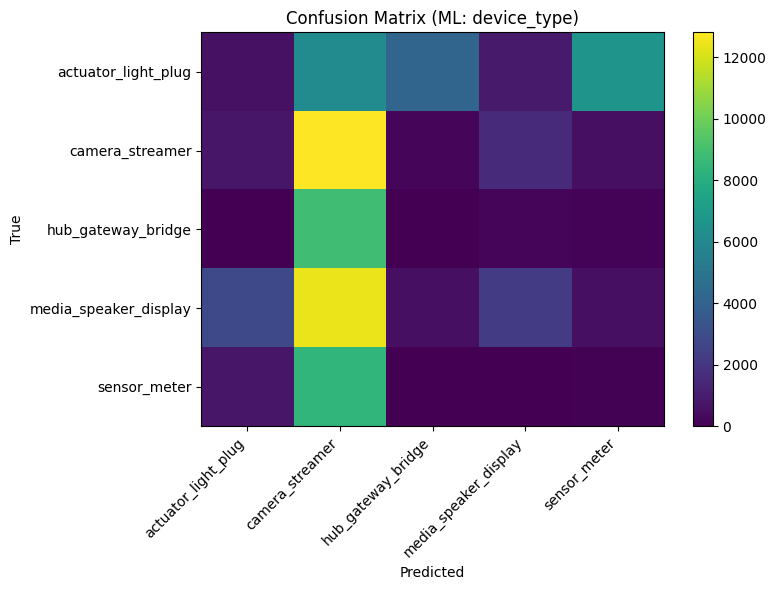

In [5]:
# 2d) Confusion matrix (ML)
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8,6))
plt.imshow(cm, aspect='auto')
plt.xticks(range(len(labels)), labels, rotation=45, ha='right')
plt.yticks(range(len(labels)), labels)
plt.title("Confusion Matrix (ML: device_type)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()
plt.tight_layout()
plt.show()


## 3) Packet-based DL — Streaming RAW vs MASKED (file-level split, repeat+steps_per_epoch)

In [6]:
# 3a) Packet preprocessing (RAW vs MASKED)
def packet_to_bytes(pkt, max_len=500, masked=False):
    """Return a fixed-length uint8 vector, or None if conversion fails."""
    try:
        p = pkt

        if masked:
            # Strip Ethernet (removes MAC addresses)
            if p.haslayer(Ether):
                p = p.payload

            # Mask IP src/dst
            if p.haslayer(IP):
                p[IP].src = "0.0.0.0"
                p[IP].dst = "0.0.0.0"
                if hasattr(p[IP], "chksum"):
                    del p[IP].chksum

            # Mask TCP/UDP ports
            if p.haslayer(TCP):
                p[TCP].sport = 0
                p[TCP].dport = 0
                if hasattr(p[TCP], "chksum"):
                    del p[TCP].chksum
            if p.haslayer(UDP):
                p[UDP].sport = 0
                p[UDP].dport = 0
                if hasattr(p[UDP], "chksum"):
                    del p[UDP].chksum

        b = bytes(p)
        arr = np.frombuffer(b, dtype=np.uint8)
        if len(arr) >= max_len:
            arr = arr[:max_len]
        else:
            arr = np.pad(arr, (0, max_len - len(arr)), mode="constant", constant_values=0)
        return arr
    except Exception:
        return None


In [7]:
# 3b) Build streaming datasets (packet-level split) for RAW and MASKED
#     - label = device id (pcap filename)
#     - split is done by packets (take/skip), NOT by file, so test contains all classes.

pcap_files = sorted(glob.glob(PCAP_DATA_GLOB))
if not pcap_files:
    raise FileNotFoundError(f"No pcaps found for pattern: {PCAP_DATA_GLOB}")

# Label space = device IDs derived from pcap filenames
classes = sorted([os.path.basename(fp).replace(".pcap", "") for fp in pcap_files])
class_to_idx = {c: i for i, c in enumerate(classes)}

print("PCAP files:", len(pcap_files))
print("Classes (device IDs):", len(classes))

def iter_packets_from_files(files, max_len=500, max_total_packets=None, masked=False):
    """Yield (x, y_idx) pairs. x is float32 [max_len], y_idx is int64."""
    total = 0
    files = list(files)
    rnd = random.Random(RANDOM_STATE + (1 if masked else 0))
    rnd.shuffle(files)

    for fp in files:
        dev = os.path.basename(fp).replace(".pcap", "")
        y_idx = class_to_idx[dev]

        with PcapReader(fp) as pcap:
            for pkt in pcap:
                arr = packet_to_bytes(pkt, max_len=max_len, masked=masked)
                if arr is None:
                    continue
                x = arr.astype(np.float32) / 255.0
                yield x, np.int64(y_idx)
                total += 1
                if max_total_packets is not None and total >= max_total_packets:
                    return

def make_dataset(files, masked=False, max_packets=None, batch_size=512, max_len=500, shuffle_buf=20000, repeat=False):
    output_signature = (
        tf.TensorSpec(shape=(max_len,), dtype=tf.float32),
        tf.TensorSpec(shape=(), dtype=tf.int64),
    )
    ds = tf.data.Dataset.from_generator(
        lambda: iter_packets_from_files(files, max_len=max_len, max_total_packets=max_packets, masked=masked),
        output_signature=output_signature
    )

    if shuffle_buf:
        ds = ds.shuffle(shuffle_buf, seed=RANDOM_STATE, reshuffle_each_iteration=True)
    if repeat:
        ds = ds.repeat()

    ds = ds.batch(batch_size)
    ds = ds.map(lambda x, y: (tf.expand_dims(x, axis=-1), y), num_parallel_calls=1)
    ds = ds.prefetch(1)
    return ds

# --- Packet-level split parameters ---
TEST_PKTS_CAP = 50_000
test_steps = int(np.ceil(TEST_PKTS_CAP / BATCH_SIZE))

steps_per_epoch = int(np.ceil(CANTIDAD_META_PKTS_PER_EPOCH / BATCH_SIZE))
print("TEST_PKTS_CAP:", TEST_PKTS_CAP, "=> test_steps:", test_steps)
print("CANTIDAD_META_PKTS_PER_EPOCH:", CANTIDAD_META_PKTS_PER_EPOCH, "=> steps_per_epoch:", steps_per_epoch)

# --- RAW: one shuffled stream over ALL packets, then split by take/skip ---
ds_all_raw = make_dataset(
    pcap_files,
    masked=False,
    max_packets=None,        # full stream
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    shuffle_buf=20000,
    repeat=False
)

ds_raw_test  = ds_all_raw.take(test_steps)             # finite
ds_raw_train = ds_all_raw.skip(test_steps).repeat()    # infinite for training

# --- MASKED: same split method, separate shuffled stream ---
ds_all_mask = make_dataset(
    pcap_files,
    masked=True,
    max_packets=None,
    batch_size=BATCH_SIZE,
    max_len=MAX_LEN,
    shuffle_buf=20000,
    repeat=False
)

ds_mask_test  = ds_all_mask.take(test_steps)
ds_mask_train = ds_all_mask.skip(test_steps).repeat()

print("Datasets ready (packet-level split).")


PCAP files: 26
Classes (device IDs): 26
TEST_PKTS_CAP: 50000 => test_steps: 98
CANTIDAD_META_PKTS_PER_EPOCH: 100000 => steps_per_epoch: 196
Datasets ready (packet-level split).


2026-01-12 17:21:41.731109: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [8]:
# 3c) DL model definition (uses Input() to avoid the warning)
def make_cnn(max_len=500, n_classes=10):
    model = Sequential([
        Input(shape=(max_len, 1)),
        Conv1D(64, 3, activation="relu"),
        MaxPooling1D(2),
        Conv1D(128, 3, activation="relu"),
        MaxPooling1D(2),
        Flatten(),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(n_classes, activation="softmax"),
    ])
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return model


In [9]:
# 3d) Train DL-RAW (packet-level split; no unseen classes)
tf.keras.backend.clear_session()
dl_raw = make_cnn(MAX_LEN, len(classes))

t0 = time.time()
hist_raw = dl_raw.fit(ds_raw_train, epochs=EPOCHS, steps_per_epoch=steps_per_epoch, verbose=1)
dl_raw_train_time = time.time() - t0

raw_loss, raw_acc = dl_raw.evaluate(ds_raw_test, verbose=0)
print(f"DL-RAW Accuracy: {raw_acc:.4f}")
print(f"DL-RAW Train time: {dl_raw_train_time:.2f}s")


Epoch 1/3


2026-01-12 17:21:53.074907: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 17260 of 20000
2026-01-12 17:21:54.588736: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.
2026-01-12 17:22:24.743845: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 65273856 exceeds 10% of free system memory.
2026-01-12 17:22:24.815337: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32636928 exceeds 10% of free system memory.
2026-01-12 17:22:24.831904: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 64749568 exceeds 10% of free system memory.
2026-01-12 17:22:24.901946: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32243712 exceeds 10% of free system memory.
2026-01-12 17:22:24.950144: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:84] Allocation of 32243712

196/196 ━━━━━━━━━━━━━━━━━━━━ 184s 724ms/step - accuracy: 0.9949 - loss: 0.0518
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 163s 834ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 206s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00


2026-01-12 17:31:06.177723: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:2: Filling up shuffle buffer (this may take a while): 10999 of 20000
2026-01-12 17:31:14.755587: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


DL-RAW Accuracy: 1.0000
DL-RAW Train time: 553.81s


2026-01-12 17:32:20.009459: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/home/uabpleb/Documents/tma_proyecto_final/TMA_lab/model/.venv/lib64/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [10]:
# 3e) Train DL-MASKED (repeat + steps_per_epoch)
# Clear session between runs to keep TF memory stable
del dl_raw
tf.keras.backend.clear_session()

dl_masked = make_cnn(MAX_LEN, len(classes))

t0 = time.time()
hist_mask = dl_masked.fit(ds_mask_train, epochs=EPOCHS, steps_per_epoch=steps_per_epoch, verbose=1)
dl_mask_train_time = time.time() - t0

mask_loss, mask_acc = dl_masked.evaluate(ds_mask_test, verbose=0)
print(f"DL-MASKED Accuracy: {mask_acc:.4f}")
print(f"DL-MASKED Train time: {dl_mask_train_time:.2f}s")


Epoch 1/3


2026-01-12 17:32:31.634359: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:11: Filling up shuffle buffer (this may take a while): 6098 of 20000
2026-01-12 17:32:41.635087: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:11: Filling up shuffle buffer (this may take a while): 11625 of 20000
2026-01-12 17:32:54.762454: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


196/196 ━━━━━━━━━━━━━━━━━━━━ 377s 1s/step - accuracy: 0.9949 - loss: 0.0700
Epoch 2/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 258s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00
Epoch 3/3
196/196 ━━━━━━━━━━━━━━━━━━━━ 252s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00


2026-01-12 17:47:18.302566: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:11: Filling up shuffle buffer (this may take a while): 6240 of 20000
2026-01-12 17:47:28.303386: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:453] ShuffleDatasetV3:11: Filling up shuffle buffer (this may take a while): 12195 of 20000
2026-01-12 17:47:40.546439: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:483] Shuffle buffer filled.


DL-MASKED Accuracy: 1.0000
DL-MASKED Train time: 887.67s


2026-01-12 17:49:15.977801: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


## 4) Plots

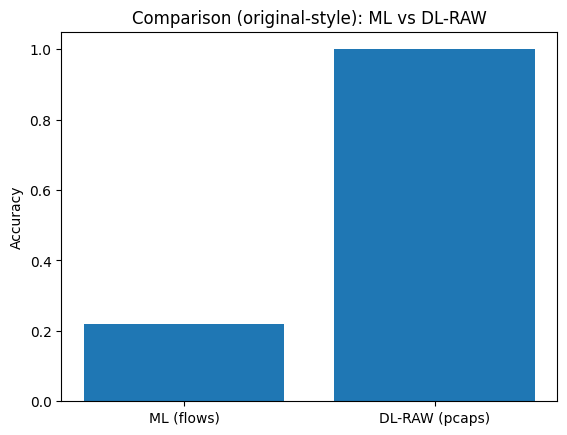

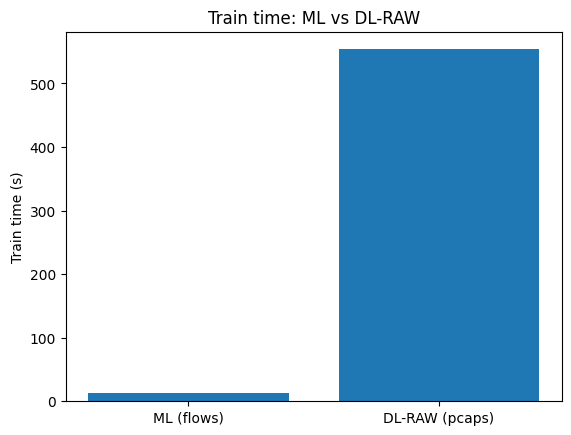

In [11]:
# Plot A: ML vs DL-RAW (original-style)
labelsA = ["ML (flows)", "DL-RAW (pcaps)"]
accA = [ml_acc, raw_acc]
timeA = [ml_train_time, dl_raw_train_time]

plt.figure()
plt.bar(labelsA, accA)
plt.ylabel("Accuracy")
plt.title("Comparison (original-style): ML vs DL-RAW")
plt.show()

plt.figure()
plt.bar(labelsA, timeA)
plt.ylabel("Train time (s)")
plt.title("Train time: ML vs DL-RAW")
plt.show()


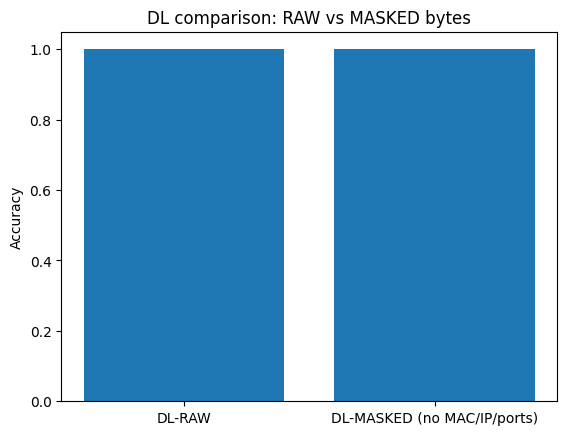

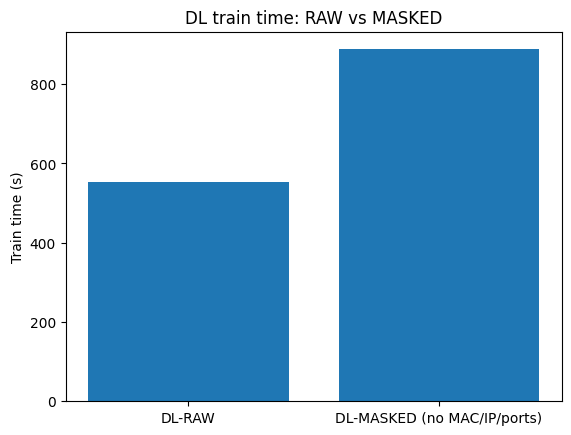

In [12]:
# Plot B: DL-RAW vs DL-MASKED (new plot)
labelsB = ["DL-RAW", "DL-MASKED (no MAC/IP/ports)"]
accB = [raw_acc, mask_acc]
timeB = [dl_raw_train_time, dl_mask_train_time]

plt.figure()
plt.bar(labelsB, accB)
plt.ylabel("Accuracy")
plt.title("DL comparison: RAW vs MASKED bytes")
plt.show()

plt.figure()
plt.bar(labelsB, timeB)
plt.ylabel("Train time (s)")
plt.title("DL train time: RAW vs MASKED")
plt.show()
